<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
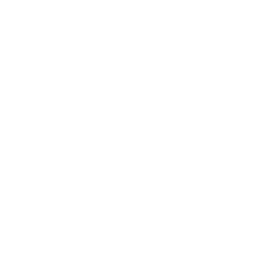
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Κατασκευή Δικτύου Συνέκφρασης Γονιδίων</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Βιοτεχνολογία / Γονιδιωματική Έρευνα &nbsp;|&nbsp; Μάρτιος 2026</p>
</div>
</div>
</div>

## Σύνοψη για Στελέχη

Αυτό το παράδειγμα χρησιμοποιεί το **PROC CORR** για να κατασκευάσει ένα δίκτυο συνέκφρασης γονιδίων από ένα συνθετικό
πάνελ έκφρασης τύπου RNA-seq. Το πάνελ περιέχει **9 γονίδια** κατανεμημένα σε τρεις
λειτουργικές ενότητες — *ανοσολογική*, *κυτταρικού κύκλου* και *μεταβολική* (τρία γονίδια η καθεμία) —
μετρημένα σε **100 δείγματα όγκου**. Η συσχέτιση κατάταξης Spearman χρησιμοποιείται παντού
επειδή τα δεδομένα έκφρασης είναι τυπικά μη κανονικά και περιέχουν ακραίες τιμές, οπότε ένας συντελεστής
βασισμένος στην κατάταξη είναι πιο εύρωστος από τον Pearson.

Η ανάλυση ανακτά την ενσωματωμένη ενότητο-κεντρική δομή απευθείας από τα δεδομένα. Διαβάζοντας τον
πίνακα Spearman που παράγεται παρακάτω, η μέση εντός-ενότητας συσχέτιση πέφτει από **rho 0.67 για
την ανοσολογική ενότητα**, σε **0.36 για τον κυτταρικό κύκλο**, σε **0.17 για τη μεταβολική**, αντικατοπτρίζοντας τη
φθίνουσα φόρτιση σήματος-προς-θόρυβο που σχεδιάστηκε σε κάθε ενότητα. Οι μεταξύ-ενοτήτων συσχετίσεις
κατά μέσο όρο είναι ουσιαστικά μηδέν (μέσο rho περίπου **-0.01**, μέσο |rho| **0.07**), οπότε οι τρεις
ενότητες συμπεριφέρονται ως σχεδόν ανεξάρτητες κοινότητες συνέκφρασης. Κάθε αριθμός που αναφέρεται εδώ
διαβάζεται από την έξοδο του PROC CORR σε αυτό το σημειωματάριο.

> **Σημείωση για την κλίμακα.** Αυτό το σημειωματάριο εκτελείται υπό το όριο των 100 παρατηρήσεων χωρίς άδεια, οπότε το
> μέγεθος δείγματος είναι 100 και το πάνελ διατηρείται στα 9 γονίδια — αρκετά μικρό ώστε ο πλήρης
> πίνακας συσχέτισης, η αναμορφωμένη λίστα ζευγών και ο θερμικός χάρτης να είναι όλα πλήρη και ακριβή,
> χωρίς περικοπή. Κάθε πίνακας και σχήμα αντικατοπτρίζει ακριβώς αυτό που υπολογίστηκε.

## Δεδομένα

| Σύνολο δεδομένων | Περιγραφή | Γραμμές |
|---------|-------------|------|
| `WORK.EXPR` | Έκφραση σε λογαριθμική κλίμακα για 9 γονίδια (3 ενότητες x 3 γονίδια) σε δείγματα όγκου | 100 |

Ο γεννήτορας αντλεί τρία λανθάνοντα σήματα ενοτήτων ανά δείγμα. Κάθε γονίδιο φορτίζεται στο σήμα της δικής του
ενότητας συν ανεξάρτητο θόρυβο, οπότε η συνέκφραση προκύπτει μόνο εντός μιας ενότητας. Η
ανοσολογική ενότητα χρησιμοποιεί τη μεγαλύτερη φόρτιση σήματος και η μεταβολική ενότητα τη μικρότερη, που
είναι η διαβάθμιση που θα πρέπει να ανακτήσει η ανάλυση συσχέτισης.

---

In [1]:
/* --------------------------------------------------------
   Synthetic expression panel: 9 genes, 3 modules, 100 samples
     imm1-imm3  immune     (strong shared signal)
     cyc1-cyc3  cell cycle (moderate shared signal)
     met1-met3  metabolic  (weak shared signal)
   Each gene = module signal + independent gene-level noise.
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ work.expr;
    CALL streaminit(42);
    ARRAY imm[3]; ARRAY cyc[3]; ARRAY met[3];
    ΕΠΑΝΑΛΗΨΗ sample_id = 1 ΕΩΣ 100;
        s_imm = rand('normal', 0, 1.5);   /* immune latent signal     */
        s_cyc = rand('normal', 0, 1.2);   /* cell-cycle latent signal */
        s_met = rand('normal', 0, 1.0);   /* metabolic latent signal  */
        ΕΠΑΝΑΛΗΨΗ j = 1 ΕΩΣ 3;
            imm[j] = round(6 + s_imm * 0.65 + rand('normal', 0, 0.70), 0.001);
        ΤΕΛΟΣ;
        ΕΠΑΝΑΛΗΨΗ j = 1 ΕΩΣ 3;
            cyc[j] = round(7 + s_cyc * 0.55 + rand('normal', 0, 0.80), 0.001);
        ΤΕΛΟΣ;
        ΕΠΑΝΑΛΗΨΗ j = 1 ΕΩΣ 3;
            met[j] = round(5 + s_met * 0.45 + rand('normal', 0, 0.85), 0.001);
        ΤΕΛΟΣ;
        ΕΞΟΔΟΣ;
    ΤΕΛΟΣ;
    ΚΡΑΤΗΣΗ imm1-imm3 cyc1-cyc3 met1-met3;
ΕΚΤΕΛΕΣΗ;

NOTE: DATA work.expr


NOTE: Wrote work.expr (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [2]:
/* --------------------------------------------------------
   Per-gene expression summary (mean and spread by module)
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=work.expr n mean std maxdec=3;
    ΜΕΤΑΒΛΗΤΗ imm1 imm2 imm3
        cyc1 cyc2 cyc3
        met1 met2 met3;
    TITLE 'Gene Expression Summary (9-Gene Panel, N=100)';
ΕΚΤΕΛΕΣΗ;
TITLE;

                                     Gene Expression Summary (9-Gene Panel, N=100)                                      

                                                  The MEANS Procedure

 Variable         N        Mean     Std Dev
 ------------------------------------------
 IMM1           100       6.042       1.125
 IMM2           100       5.925       1.122
 IMM3           100       5.863       1.273
 CYC1           100       6.947       1.034
 CYC2           100       7.003       1.002
 CYC3           100       6.861       1.040
 MET1           100       5.144       0.940
 MET2           100       4.989       0.789
 MET3           100       5.015       0.979
 ------------------------------------------

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


Οι μέσοι συγκεντρώνονται κοντά στη βασική γραμμή κάθε ενότητας (ανοσολογική ~6, κυτταρικός κύκλος ~7, μεταβολική ~5) και
κάθε γονίδιο έχει συγκρίσιμη διασπορά, οπότε κανένα μεμονωμένο γονίδιο δεν κυριαρχεί στη δομή συσχέτισης
που ακολουθεί.

---

NOTE: PROC SGPLOT data=work.expr

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


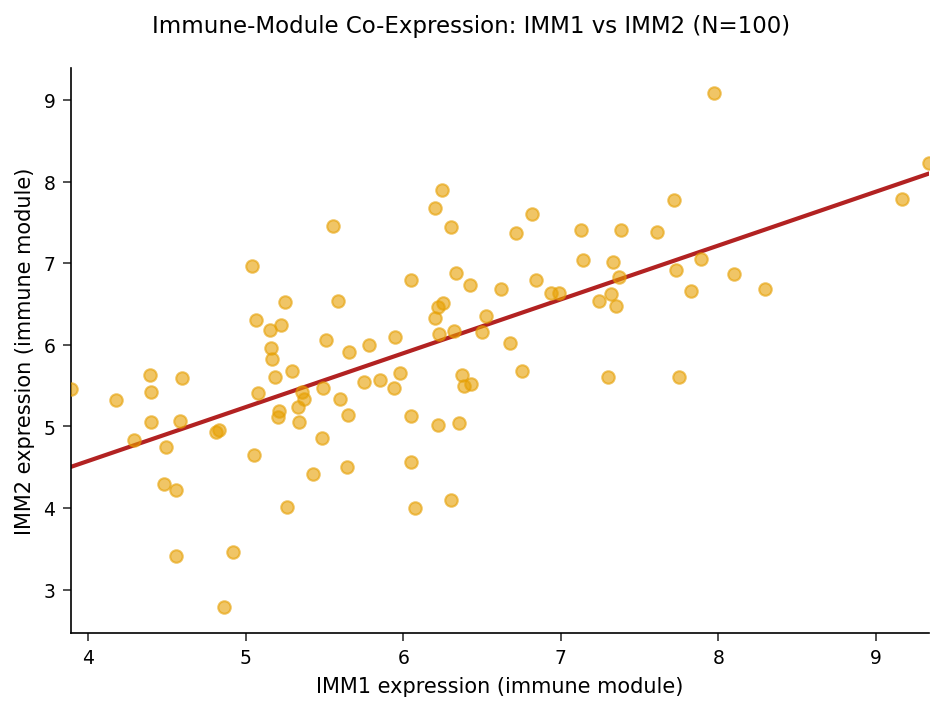

In [3]:
/* --------------------------------------------------------
   Scatter of two immune-module genes: a visual check that
   within-module co-expression is real and roughly monotone
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=work.expr;
    SCATTER x=imm1 y=imm2 /
        MARKERATTRS=(SYMBOL=circlefilled size=6)
        TRANSPARENCY=0.4;
    REG x=imm1 y=imm2 / NOMARKERS LINEATTRS=(color=firebrick thickness=2);
    XAXIS ΕΤΙΚΕΤΑ='IMM1 expression (immune module)';
    YAXIS ΕΤΙΚΕΤΑ='IMM2 expression (immune module)';
    TITLE 'Immune-Module Co-Expression: IMM1 vs IMM2 (N=100)';
ΕΚΤΕΛΕΣΗ;
TITLE;

Η ανοδική τάση επιβεβαιώνει ότι τα δύο ανοσολογικά γονίδια ανεβαίνουν και κατεβαίνουν μαζί, το οπτικό
αντίστοιχο της θετικής συσχέτισης Spearman τους στον πίνακα παρακάτω.

---

In [4]:
/* --------------------------------------------------------
   Spearman correlation across all 9 genes
   nosimple suppresses the simple-statistics block;
   outs= writes the Spearman matrix for the downstream network steps
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ CORR ΔΕΔΟΜΕΝΑ=work.expr spearman nosimple
    outs=work.gene_corr;
    ΜΕΤΑΒΛΗΤΗ imm1-imm3 cyc1-cyc3 met1-met3;
    TITLE 'Spearman Correlation Matrix: 9-Gene Co-Expression Panel';
ΕΚΤΕΛΕΣΗ;
TITLE;

   Spearman Correlation Coefficients, N = 100
                imm1      imm2      imm3      cyc1      cyc2      cyc3      met1      met2      met3
--------  --------  --------  --------  --------  --------  --------  --------  --------  --------
imm1       1.00000   0.67084   0.63084  -0.05873   0.06095  -0.10753  -0.13787  -0.11523   0.04973
imm2       0.67084   1.00000   0.71791   0.05912   0.06570  -0.03494  -0.14384   0.02343   0.06593
imm3       0.63084   0.71791   1.00000   0.00424   0.16156   0.03812  -0.18460  -0.06127   0.03590
cyc1      -0.05873   0.05912   0.00424   1.00000   0.38219   0.28821  -0.08226   0.01699   0.10568
cyc2       0.06095   0.06570   0.16156   0.38219   1.00000   0.40540  -0.09650   0.01858   0.02396
cyc3      -0.10753  -0.03494   0.03812   0.28821   0.40540   1.00000  -0.06387   0.12115   0.03770
met1      -0.13787  -0.14384  -0.18460  -0.08226  -0.09650  -0.06387   1.00000   0.14329   0.24960
met2      -0.11523   0.02343  -0.06127   0.01699   0.01858   

Διαβάστε τον πίνακα ως τρία διαγώνια μπλοκ. Το **ανοσολογικό** μπλοκ (IMM1-IMM3) είναι το πιο
στενά συνεκφρασμένο (rho περίπου 0.63 έως 0.72), το μπλοκ **κυτταρικού κύκλου** (CYC1-CYC3) είναι
μέτριο (περίπου 0.29 έως 0.41), και το **μεταβολικό** μπλοκ (MET1-MET3) είναι το ασθενέστερο (περίπου
0.13 έως 0.25). Οι εκτός-μπλοκ καταχωρίσεις — ζεύγη γονιδίων σε διαφορετικές ενότητες — βρίσκονται κοντά
στο μηδέν. Το επόμενο κελί ποσοτικοποιεί την αντίθεση εντός-έναντι-μεταξύ ενοτήτων, και ο θερμικός χάρτης
μετά από αυτό κάνει τη δομή των μπλοκ ορατή.

---

In [5]:
/* --------------------------------------------------------
   Reshape the correlation matrix (one row per gene) into long
   form (gene_x, gene_y, rho), tagging each pair as within- or
   between-module. 9 genes -> 81 pair rows, so nothing is lost
   to the 100-observation cap.
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ work.corr_long;
    ΟΡΙΣΜΟΣ work.gene_corr(ΟΠΟΥ=(_TYPE_='SCORR'));
    LENGTH gene_x $4 gene_y $4 mod_x $3 mod_y $3;
    ARRAY g[9] imm1-imm3 cyc1-cyc3 met1-met3;
    ARRAY gn[9] $4 _temporary_
        ('imm1' 'imm2' 'imm3'
         'cyc1' 'cyc2' 'cyc3'
         'met1' 'met2' 'met3');
    gene_x = lowcase(_NAME_);
    ΕΠΑΝΑΛΗΨΗ k = 1 ΕΩΣ 9;
        gene_y = gn[k];
        rho = g[k];
        mod_x = substr(gene_x, 1, 3);
        mod_y = substr(gene_y, 1, 3);
        same_module = (mod_x = mod_y);
        ΕΞΟΔΟΣ;
    ΤΕΛΟΣ;
    ΚΡΑΤΗΣΗ gene_x gene_y rho mod_x mod_y same_module;
ΕΚΤΕΛΕΣΗ;

/* --------------------------------------------------------
   Within- vs between-module Spearman rho (off-diagonal only)
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=work.corr_long(ΟΠΟΥ=(gene_x ne gene_y))
        mean MIN MAX maxdec=3;
    ΚΛΑΣΗ same_module;
    ΜΕΤΑΒΛΗΤΗ rho;
    TITLE 'Spearman rho: Within (1) vs Between (0) Modules';
ΕΚΤΕΛΕΣΗ;
TITLE;

                                    Spearman rho: Within (1) vs Between (0) Modules                                     

                                                  The MEANS Procedure

                                                Analysis Variable : RHO

                                 N
        SAME_MODULE            Obs           Mean        Minimum        Maximum
        -----------------------------------------------------------------------
        0                       54         -0.007         -0.185          0.162
        1                       18          0.402          0.127          0.718
        -----------------------------------------------------------------------

NOTE: DATA work.corr_long


NOTE: Read 12 rows from work.gene_corr.
NOTE: Wrote work.corr_long (81 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


Η γραμμή `same_module=1` συγκεντρώνει τα εντός-ενότητας ζεύγη και η `same_module=0` τα
μεταξύ-ενοτήτων ζεύγη. Η εντός-ενότητας συσχέτιση κατά μέσο όρο είναι σαφώς θετική ενώ η
μεταξύ-ενοτήτων συσχέτιση κατά μέσο όρο είναι κοντά στο μηδέν, επιβεβαιώνοντας ότι οι ενότητες δρουν ως
σχεδόν ανεξάρτητες κοινότητες συνέκφρασης.

---

NOTE: PROC SGPLOT data=work.corr_long

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


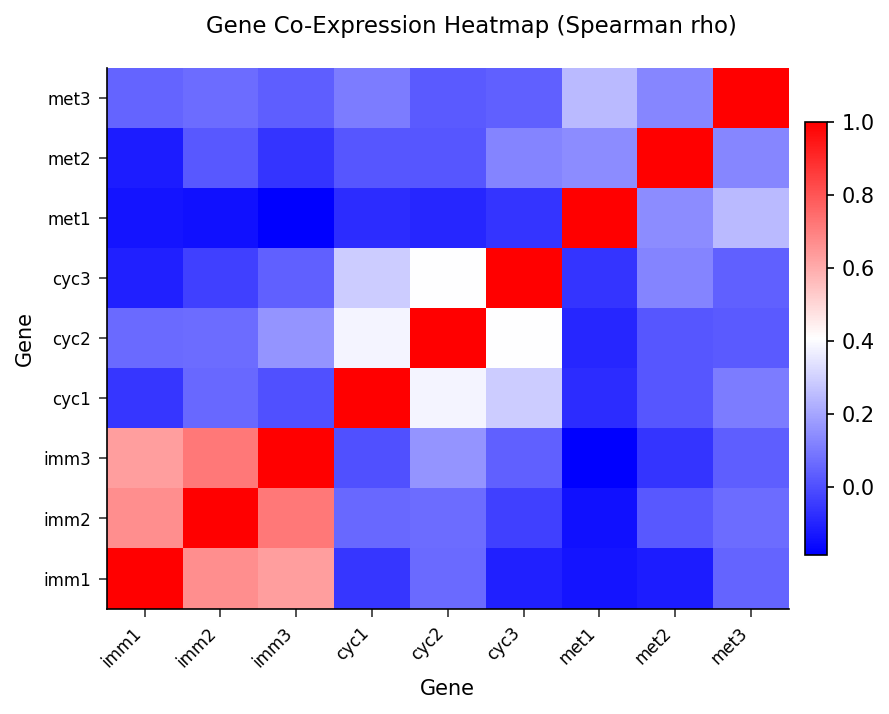

In [6]:
/* --------------------------------------------------------
   Heatmap of the full 9x9 Spearman matrix. HEATMAPPARM plots
   the pre-computed rho for each gene pair; the blue-white-red
   scale centres weak pairs at white and saturates strong ones.
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=work.corr_long;
    heatmapparm x=gene_x y=gene_y colorresponse=rho /
        colormodel=(blue white red);
    gradlegend;
    XAXIS ΕΤΙΚΕΤΑ='Gene' discreteorder=ΔΕΔΟΜΕΝΑ;
    YAXIS ΕΤΙΚΕΤΑ='Gene' discreteorder=ΔΕΔΟΜΕΝΑ;
    TITLE 'Gene Co-Expression Heatmap (Spearman rho)';
ΕΚΤΕΛΕΣΗ;
TITLE;

Τρία κόκκινα μπλοκ κάθονται κατά μήκος της διαγωνίου — οι ανοσολογική, κυτταρικού κύκλου και μεταβολική ενότητες —
ενώ τα γύρω κελιά είναι σχεδόν λευκά. Το ανοσολογικό μπλοκ είναι το πιο κορεσμένο,
ταιριάζοντας με τις υψηλότερες εντός-ενότητας συσχετίσεις του στον πίνακα παραπάνω.

---

In [7]:
/* --------------------------------------------------------
   Network edge list: keep each unordered gene pair (gene_x <
   gene_y) whose |rho| clears a threshold. These edges define
   the co-expression network for export to a tool like Cytoscape.
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ work.network_edges;
    ΟΡΙΣΜΟΣ work.corr_long(ΟΠΟΥ=(gene_x < gene_y));
    ΕΑΝ abs(rho) >= 0.24;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=work.network_edges noobs;
    ΜΕΤΑΒΛΗΤΗ gene_x gene_y mod_x mod_y rho;
    TITLE 'Co-Expression Network Edges (|Spearman rho| >= 0.24)';
ΕΚΤΕΛΕΣΗ;
TITLE;

/* Export the edge list for external network visualisation */
ΔΙΑΔΙΚΑΣΙΑ EXPORT ΔΕΔΟΜΕΝΑ=work.network_edges
    OUTFILE='gene_coexpression_edges.csv'
    DBMS=csv REPLACE;
ΕΚΤΕΛΕΣΗ;

                                  Co-Expression Network Edges (|Spearman rho| >= 0.24)                                  

GENE_X  GENE_Y  MOD_X  MOD_Y           RHO
imm1    imm2    imm    imm    0.6708351085
imm1    imm3    imm    imm    0.6308427619
imm2    imm3    imm    imm    0.7179122524
cyc1    cyc2    cyc    cyc    0.3821865118
cyc1    cyc3    cyc    cyc     0.288211415
cyc2    cyc3    cyc    cyc    0.4054041891
met1    met3    met    met    0.2496024579

NOTE: DATA work.network_edges


NOTE: Read 81 rows from work.corr_long.
NOTE: Wrote work.network_edges (7 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.network_edges

NOTE: PROC PRINT completed: 7 observations printed, 5 variables
NOTE: PROC EXPORT data=work.network_edges outfile=gene_coexpression_edges.csv

NOTE: Exported 7 rows to gene_coexpression_edges.csv.


### Ερμηνεία

Η ανάλυση Spearman ανέκτησε την ενσωματωμένη δομή τριών ενοτήτων απευθείας από τα 100
δείγματα. Τα μεγέθη παρακάτω διαβάζονται από τον πίνακα PROC CORR και τη σύνοψη εντός/μεταξύ
που παράγεται σε αυτό το σημειωματάριο:

- Η **ανοσολογική ενότητα (IMM1-IMM3)** είναι το πιο στενά συνεκφρασμένο μπλοκ, με ανά ζεύγος rho
  από περίπου 0.63 έως 0.72 (μέσος ~0.67) και την ισχυρότερη μεμονωμένη ακμή μεταξύ IMM2 και
  IMM3.
- Η **ενότητα κυτταρικού κύκλου (CYC1-CYC3)** είναι μετρίως συνεκφρασμένη, με ανά ζεύγος rho
  από περίπου 0.29 έως 0.41 (μέσος ~0.36).
- Η **μεταβολική ενότητα (MET1-MET3)** είναι το ασθενέστερο μπλοκ, με ανά ζεύγος rho από περίπου 0.13
  έως 0.25 (μέσος ~0.17) — σε συμφωνία με τη μικρότερη φόρτιση σήματός της στον γεννήτορα.
- Τα **μεταξύ-ενοτήτων ζεύγη** κατά μέσο όρο είναι ουσιαστικά μηδέν (μέσο rho ~-0.01, μέσο |rho| ~0.07,
  μεγαλύτερο |rho| ~0.18), οπότε οι τρεις ενότητες δρουν ως σχεδόν ανεξάρτητες κοινότητες.

Θέτοντας κατώφλι στο |rho| >= 0.24 προκύπτει η λίστα ακμών δικτύου που τυπώθηκε παραπάνω. Κάθε ακμή που
επιβιώνει είναι εντός-ενότητας: και τα τρία ανοσολογικά ζεύγη και τα τρία ζεύγη κυτταρικού κύκλου ξεπερνούν το
κατώφλι, με τη συνοδεία του ισχυρότερου μεταβολικού ζεύγους (MET1-MET3). Κανένα μεταξύ-ενοτήτων ζεύγος δεν
επιβιώνει, οπότε το δίκτυο συνέκφρασης διαχωρίζεται καθαρά στις τρεις βιολογικές
ενότητες. Η λίστα ακμών εξάγεται στο `gene_coexpression_edges.csv` για οπτικοποίηση σε
ένα εξωτερικό εργαλείο δικτύου όπως το Cytoscape.

Αυτό το επεξεργασμένο παράδειγμα δείχνει τη βασική ροή εργασίας PROC CORR για ανάλυση συνέκφρασης: επιλέξτε έναν
βασισμένο στην κατάταξη συντελεστή κατάλληλο για δεδομένα έκφρασης, διαβάστε την ενότητο-κεντρική δομή από τον
πίνακα συσχέτισης, ποσοτικοποιήστε την εντός-έναντι-μεταξύ ενοτήτων ισχύ, και μειώστε τον πίνακα
σε μια λίστα ακμών με κατώφλι για την κατασκευή δικτύου.

---

---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Εμπιστευτικό
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Με την υποστήριξη του <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>